In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# 1. Connection setup
GCP_PROJECT_ID = "ds6-module-2-olist-analytics"
DATASET_NAME = "ingestion"
engine = create_engine(f"bigquery://{GCP_PROJECT_ID}/{DATASET_NAME}")

# 2. Query using IFNULL to handle missing category names
pareto_query = """
    SELECT 
        IFNULL(p.product_category_name_eng, IFNULL(p.product_category_name, 'Unknown')) AS category_name,
        SUM(SAFE_CAST(i.price AS FLOAT64)) AS total_revenue,
        COUNT(DISTINCT i.order_id) AS total_orders
    FROM order_items i
    JOIN products p 
        ON i.product_id = p.product_id
    GROUP BY 1
    ORDER BY total_revenue DESC
"""

# Load into Pandas
df_category = pd.read_sql(pareto_query, con=engine)

# 3. Perform 80/20 Pareto Calculation
df_category['cumulative_revenue'] = df_category['total_revenue'].cumsum()
total_revenue = df_category['total_revenue'].sum()
df_category['cumulative_percentage'] = (df_category['cumulative_revenue'] / total_revenue) * 100

# Classify categories for Inventory Strategy
def assign_tier(pct):
    if pct <= 80:
        return 'Tier A: Stock Heavily (Top 80% Revenue)'
    elif pct <= 95:
        return 'Tier B: Maintain Standard Stock (Next 15%)'
    else:
        return 'Tier C: Discount / Discontinue (Bottom 5%)'

df_category['inventory_action'] = df_category['cumulative_percentage'].apply(assign_tier)

print("--- Category Revenue Summary ---")
print(df_category[['category_name', 'total_revenue', 'cumulative_percentage', 'inventory_action']].head(10))

--- Category Revenue Summary ---
           category_name  total_revenue  cumulative_percentage  \
0          health_beauty     2186301.66               9.189425   
1          watches_gifts     2133782.37              18.158102   
2         bed_bath_table     1819495.37              25.805773   
3         sports_leisure     1712354.31              33.003110   
4  computers_accessories     1593769.68              39.702015   
5        furniture_decor     1281455.65              45.088207   
6             housewares     1108701.58              49.748282   
7             cool_stuff     1102334.77              54.381597   
8                   auto     1026815.33              58.697489   
9           garden_tools      858235.92              62.304811   

                          inventory_action  
0  Tier A: Stock Heavily (Top 80% Revenue)  
1  Tier A: Stock Heavily (Top 80% Revenue)  
2  Tier A: Stock Heavily (Top 80% Revenue)  
3  Tier A: Stock Heavily (Top 80% Revenue)  
4  Tier A: Stoc

In [2]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("bigquery://ds6-module-2-olist-analytics/ingestion")
print(pd.read_sql("SELECT * FROM products LIMIT 1", con=engine).columns.tolist())

['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_eng', '_sdc_extracted_at', '_sdc_received_at', '_sdc_batched_at', '_sdc_deleted_at', '_sdc_sequence', '_sdc_table_version', '_sdc_sync_started_at']


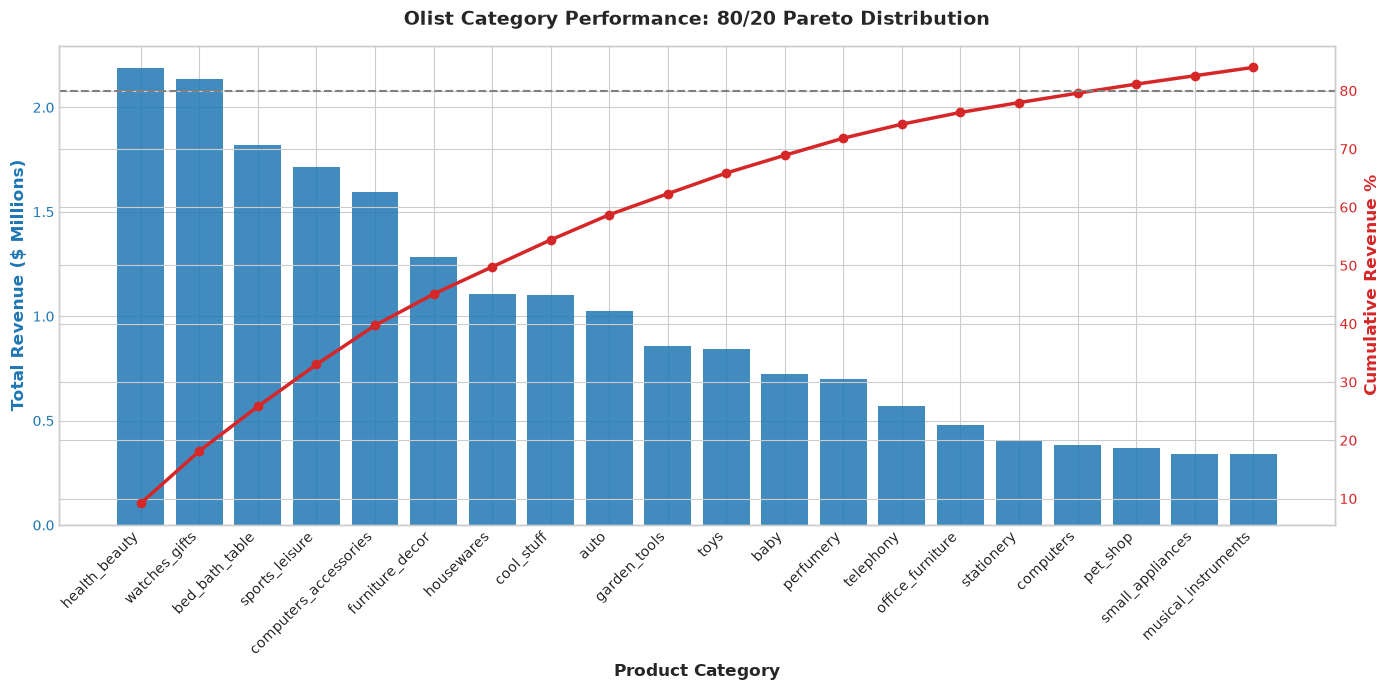

Chart successfully saved as 'pareto_chart.png'!


In [5]:
import numpy as np

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Top 20 categories for visual clarity
df_plot = df_category.head(20).copy()

# Primary Axis: Bar plot for individual revenue
color_bar = '#1f77b4'
bars = ax1.bar(df_plot['category_name'], df_plot['total_revenue'] / 1e6, color=color_bar, alpha=0.85)
ax1.set_xlabel('Product Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Revenue ($ Millions)', color=color_bar, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_bar)
plt.xticks(rotation=45, ha='right')

# Secondary Axis: Cumulative percentage line
ax2 = ax1.twinx()
color_line = '#d62728'
line = ax2.plot(df_plot['category_name'], df_plot['cumulative_percentage'], color=color_line, marker='o', linewidth=2.5)
ax2.set_ylabel('Cumulative Revenue %', color=color_line, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)

# Add 80% Pareto Reference Line
ax2.axhline(80, color='gray', linestyle='--', linewidth=1.5, label='80% Revenue Cutoff')

plt.title('Olist Category Performance: 80/20 Pareto Distribution', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()

# Save image for Steiner's pitch deck
plt.savefig('pareto_chart.png', dpi=300)
plt.show()
print("Chart successfully saved as 'pareto_chart.png'!")